## Modeling Pipeline

- **Baseline Model Development:** A standard model was trained using default/reasonable hyperparameters to establish a performance benchmark for each of the 6 algorithms (ARIMA, XGBoost, LightGBM, LSTM, CatBoost, Prophet).

- **Hyperparameter Optimization:** Each baseline model was optimized using two complementary techniques:
  - ***`Optuna`*** (Bayesian Optimization): Efficient, adaptive search with pruning for rapid convergence to high-performing configurations.
  - ***`RandomizedSearchCV`*** (Random Search with CV): Sklearn-compatible baseline optimization for fair comparison and reproducibility.
  - *Note: ARIMA and Prophet used model-specific optimization strategies due to API constraints.*

- **Cross-Validation and Robustness Assessment:** Each model variant was evaluated using ***`TimeSeriesSplit`*** (not random KFold) to preserve temporal order and prevent look-ahead bias. Metrics were aggregated across folds to assess stability.

- **Overfitting Analysis:** A detailed comparison between cross-validation metrics and test set results was conducted. Additional metrics, including ***`RMSE ratio`*** and ***`R² gap`***, were computed to quantify overfitting and assess model generalization. Directional accuracy and financial metrics (Sharpe Ratio, Max Drawdown) were also calculated for trading-relevant evaluation.

---

## Persisted Artifacts

To ensure reproducibility, transparency, and extendability, the following artifacts have been saved for **each model**:

- **Optimized Model Performance:** Individual CSV files capturing the performance of each model variant:
    - ***[Model] (Baseline)***
    - ***[Model] (Optuna)***
    - ***[Model] (RandomizedSearchCV)***

- **Best Variation Performance:** A CSV file containing only the metrics of the best-performing variation per model.

- **Summary of Model Performance:** A consolidated, extendable CSV file (`a_ModelPerformance.csv`) including:
    - Cross-validation results (`CV MSE`, `CV MAE`, `CV RMSE`, `CV R²`, `CV MAPE`)
    - Test set results (`Test MSE`, `Test MAE`, `Test RMSE`, `Test R²`, `Test MAPE`)
    - Financial metrics (`Sharpe Ratio`, `Sortino Ratio`, `Max Drawdown`, `Directional Accuracy`)
    - Overfitting metrics (`R² gap`, `RMSE ratio`)
    - Overfitting status and model generalization label

- **Overfitting DataFrame:** An extendable CSV (`a_OverfittingAnalysis.csv`) capturing overfitting analysis metrics across all models and variations.

- **Best Model per Algorithm:** The serialized best-performing variant of each algorithm for ensemble consideration or deployment.

- **Model Comparison Dashboard:** A summary notebook or script that loads `a_ModelPerformance.csv` and generates publication-ready comparison visualizations.

Together, these artifacts provide a complete, reproducible record of the modeling process, facilitating model tracking, comparison, selection, and deployment.

## Import Libraries and Root Configuration

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
project_root = Path(os.getcwd()).parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# records and calculations
import pandas as pd
import numpy as np

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')

# read file path
from pathlib import Path

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from scipy.stats import uniform, randint

# gradient boosting model
import xgboost as xgb

# optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# import helper functions
from utilities import Evaluator, DataHandler, ModelPersister

## Load Dataset and Artifacts

In [3]:
df, x, y = DataHandler.load_dataset("../data/encoded_dataset.csv")
artifacts = DataHandler.load_artifacts("../artifacts/feature-selection", cv_required=True)

In [4]:
# check dataset loading
df.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3,OutletSales
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,7.777469
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,8.040434
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,7.025718
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.650018
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,8.348656


In [5]:
# check input features
x.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [6]:
# check target feature
y.head()

0    7.777469
1    8.040434
2    7.025718
3    5.650018
4    8.348656
Name: OutletSales, dtype: float64

In [7]:
# load train/test split data
x_train, x_test, y_train, y_test = artifacts['x_train'], artifacts['x_test'], artifacts['y_train'], artifacts['y_test']
cv = artifacts['cv']

# Baseline Modeling

## Train XGBoost Model

In [8]:
# create baseline model
baseline_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)

# train baseline mode
baseline_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Apply Model to Make Predication

In [9]:
# baseline prediction on train and test set
y_train_pred_baseline = baseline_model.predict(x_train)
y_test_pred_baseline = baseline_model.predict(x_test)

## Evaluating Model Performance
Calculating Errors for train and test data

In [10]:
# evaluation of train metrics
train_metrics_baseline = Evaluator.calculate_metrics(y_train, y_train_pred_baseline)

# evaluation of test metrics
test_metrics_baseline = Evaluator.calculate_metrics(y_test, y_test_pred_baseline)

In [11]:
# Baseline Model Performance
baseline_perf = Evaluator.performance_table(train_metrics_baseline, test_metrics_baseline)

print("XGBoost - Baseline Modeling Performance")
display(baseline_perf)

XGBoost - Baseline Modeling Performance


,Metrics,Training,Test
0,MSE,0.1806,0.2791
1,MAE,0.3280,0.4102
2,RMSE,0.4250,0.5283
3,R2 Score,0.8244,0.7356
4,MAPE,4.6901,6.0370


# Optuna Optimzation

## Find Best Parameters

In [12]:
# define objective function
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10, log=True),
        "random_state": 42,
        "verbosity": 0
    }

    model = xgb.XGBRegressor(**params)
    model.fit(x_train, y_train)

    return np.sqrt(mean_squared_error(y_train, model.predict(x_train)))

In [13]:
# create study object
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))

# optimize hyperparameters
study.optimize(objective, n_trials=50, show_progress_bar=False)

# best parameter from optuna
best_params_optuna = study.best_params

## Train optimized model and Apply Model to Make Predictions

In [14]:
# train optimized model
optuna_model = xgb.XGBRegressor(**best_params_optuna, random_state=42, verbosity=0)
optuna_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.815050995731589
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
# apply model to make predictions on train and test set
y_train_pred_optuna = optuna_model.predict(x_train)
y_test_pred_optuna = optuna_model.predict(x_test)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [16]:
# calculate train and test metrics
# return [mse, mae, rmse, r2, mape]
train_metrics_optuna = Evaluator.calculate_metrics(y_train, y_train_pred_optuna)
test_metrics_optuna = Evaluator.calculate_metrics(y_test, y_test_pred_optuna)

In [17]:
# performance table of optuna optimization
optuna_perf = Evaluator.performance_table(train_metrics_optuna, test_metrics_optuna)

print("XGBoost - Optuna Optimized Modeling Performance")
display(optuna_perf)

XGBoost - Optuna Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.0185,0.3457
1,MAE,0.1032,0.4581
2,RMSE,0.1360,0.5880
3,R2 Score,0.9820,0.6724
4,MAPE,1.4496,6.6765


#  RandomizedSearchCV Optimzation

## Train RandomizedSearchCV Model

In [18]:
# parameter distribution
param_dist = {
    "n_estimators": randint(100, 1000),
    "learning_rate": uniform(0.01, 0.29),
    "max_depth": randint(3, 13),
    "min_child_weight": uniform(1, 9),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(1e-6, 10),
    "reg_lambda": uniform(1e-6, 10),
}

# create empty model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)

In [19]:
# optimize with RandomSearchCV
random_search = RandomizedSearchCV(model,
                                   param_dist,
                                   n_iter=50,
                                   scoring='neg_root_mean_squared_error',
                                   cv=cv,
                                   random_state=42,
                                   n_jobs=-1)

# fit model
random_search.fit(x_train, y_train)

# best model from RandomSearchCV
randomSearch_model = random_search.best_estimator_

## Apply Model to Make Predictions

In [20]:
# make predictions on train and test set
y_train_pred_random = randomSearch_model.predict(x_train)
y_test_pred_random = randomSearch_model.predict(x_test)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [21]:
# calculate train and test metrics
train_metrics_random = Evaluator.calculate_metrics(y_train, y_train_pred_random)
test_metrics_random = Evaluator.calculate_metrics(y_test, y_test_pred_random)

In [22]:
# performance table of optuna optimization
random_perf = Evaluator.performance_table(train_metrics_random, test_metrics_random)

print("XGBoost - RandomSearchCV Optimized Modeling Performance")
display(random_perf)

XGBoost - RandomSearchCV Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.2641,0.2686
1,MAE,0.3964,0.4011
2,RMSE,0.5139,0.5183
3,R2 Score,0.7432,0.7455
4,MAPE,5.7476,5.9102


# Cross Valiation (All Models)

In [23]:
# cross validation of all models
cv_baseline = Evaluator.cv_evaluate(baseline_model, x_train, y_train, cv)
cv_optuna = Evaluator.cv_evaluate(optuna_model, x_train, y_train, cv)
cv_random = Evaluator.cv_evaluate(randomSearch_model, x_train, y_train, cv)

In [24]:
# Evaluate cross-validation results
cv_df = pd.DataFrame({
    "Model": ["XGBoost (Baseline)", "XGBoost (Optuna)", "XGBoost (RandomSearchCV)"],
    "CV MSE": [cv_baseline['CV MSE'], cv_optuna['CV MSE'], cv_random['CV MSE']],
    "CV MAE": [cv_baseline['CV MAE'], cv_optuna['CV MAE'], cv_random['CV MAE']],
    "CV RMSE": [cv_baseline['CV RMSE'], cv_optuna['CV RMSE'], cv_random['CV RMSE']],
    "CV R2": [cv_baseline['CV R2'], cv_optuna['CV R2'], cv_random['CV R2']],
    "CV MAPE": [cv_baseline['CV MAPE'], cv_optuna['CV MAPE'], cv_random['CV MAPE']]
}).round(4)

print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE
0,XGBoost (Baseline),0.2911,0.4186,0.5396,0.7166,6.0787
1,XGBoost (Optuna),0.3598,0.4676,0.5998,0.6496,6.7381
2,XGBoost (RandomSearchCV),0.2730,0.4038,0.5225,0.7342,5.8700


# Summarize Models Performance

In [25]:
# selected models
models = ['XGBoost (Baseline)', 'XGBoost (Optuna)', 'XGBoost (RandomSearchCV)']

# test metrics of all models
test_metrics = [test_metrics_baseline, test_metrics_optuna, test_metrics_random]

# performance summary including cross validation results
performance_summary = Evaluator.summary_builder(models, cv_df, test_metrics)

In [26]:
# Display the final performance summary table
print("Overall Model Performance:")
display(performance_summary)

Overall Model Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE
0,XGBoost (Baseline),0.2911,0.4186,0.5396,0.7166,6.0787,0.2791,0.4102,0.5283,0.7356,6.0370
1,XGBoost (Optuna),0.3598,0.4676,0.5998,0.6496,6.7381,0.3457,0.4581,0.5880,0.6724,6.6765
2,XGBoost (RandomSearchCV),0.2730,0.4038,0.5225,0.7342,5.8700,0.2686,0.4011,0.5183,0.7455,5.9102


# Overfitting Analysis

In [27]:
# Overfitting analysis of all models

rows = []
for _, row in performance_summary.iterrows():
    # Extract metrics needed for assess_overfitting
    cv_r2 = row['CV R2']
    test_r2 = row['Test R2']
    cv_rmse = row['CV RMSE']
    test_rmse = row['Test RMSE']
    
    # get overfitting and generalization status
    gap, rmse_ratio, overfit_status, gen_status = Evaluator.assess_overfitting(
        cv_r2=cv_r2,
        test_r2=test_r2,
        cv_rmse=cv_rmse,
        test_rmse=test_rmse,
        tolerance=0.05
    )
    
    # build row
    rows.append({
        "Model": row['Model'],
        "CV RMSE": row['CV RMSE'],
        "CV R2": row['CV R2'],
        "Test RMSE": row['Test RMSE'],
        "Test R2": row['Test R2'],
        "R2 Gap": gap,
        "RMSE Ratio": rmse_ratio,
        "Overfitting Status": overfit_status,
        "Model Status (Generalization)": gen_status
    })

overfit_df = pd.DataFrame(rows).round(4)

In [28]:
print("XGBoost - Overfitting Analysis:")
display(overfit_df)

XGBoost - Overfitting Analysis:


,Model,CV RMSE,CV R2,Test RMSE,Test R2,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,XGBoost (Baseline),0.5396,0.7166,0.5283,0.7356,-0.0190,0.9791,Low,Good
1,XGBoost (Optuna),0.5998,0.6496,0.5880,0.6724,-0.0228,0.9803,Low,Fair
2,XGBoost (RandomSearchCV),0.5225,0.7342,0.5183,0.7455,-0.0113,0.9920,Low,Good


# Model Comparison (Visualization)

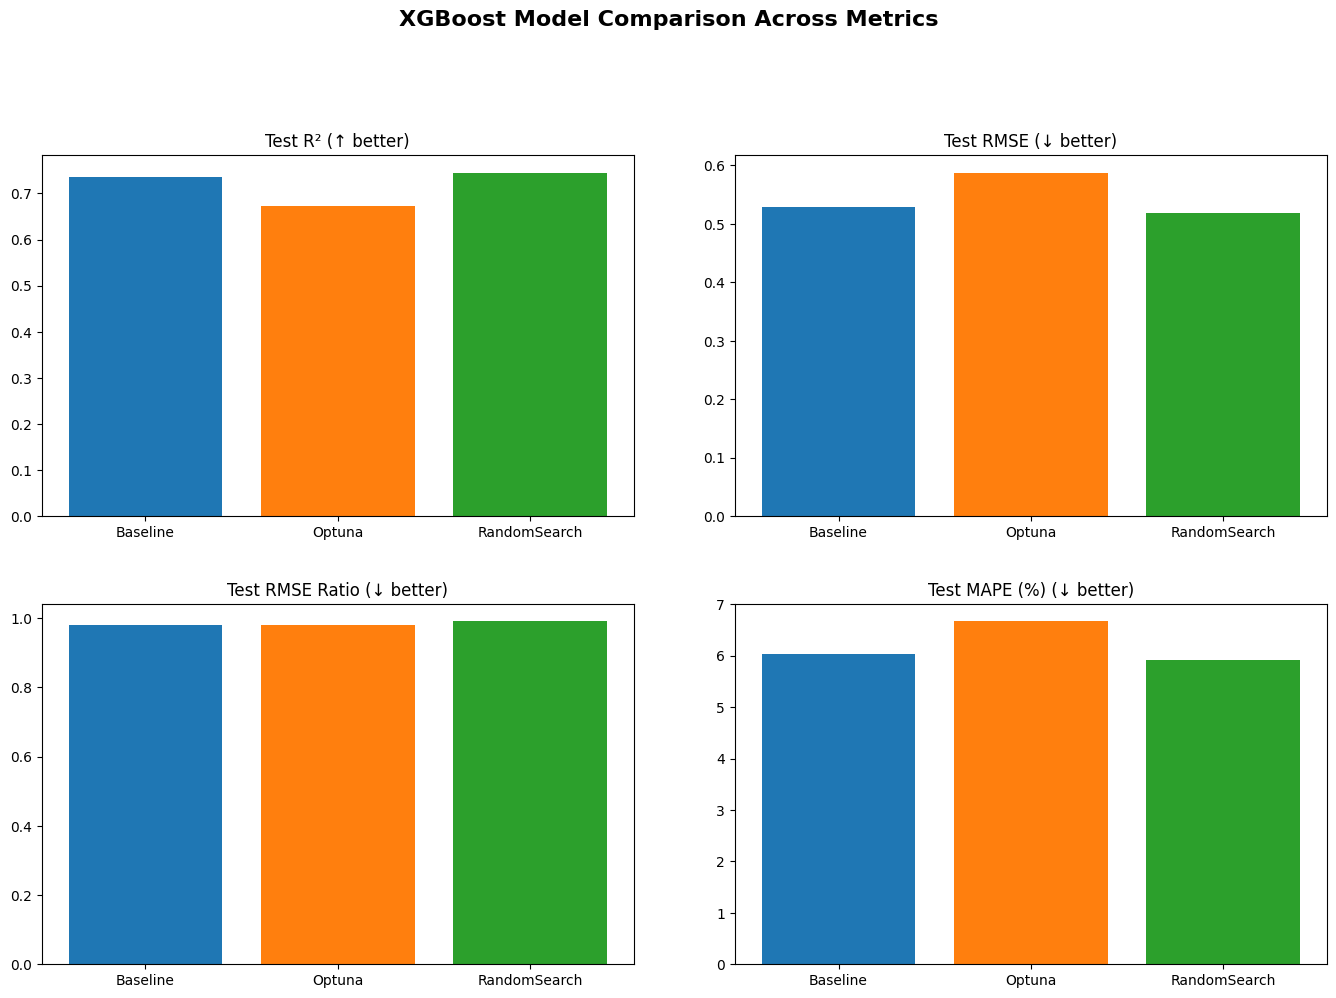

In [29]:
""" XGBoost Model Performance Comparison """

# Define metrics and titles
metrics = [
    "Test R2",
    "Test RMSE",
    "RMSE Ratio",
    "Test MAPE"
]

titles = [
    "Test R² (↑ better)",
    "Test RMSE (↓ better)",
    "Test RMSE Ratio (↓ better)",
    "Test MAPE (%) (↓ better)"
]

# Data preparation
model_labels = ["Baseline", "Optuna", "RandomSearch"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

values_dict = {
    "Test R2": overfit_df["Test R2"].values,
    "Test RMSE": overfit_df["Test RMSE"].values,
    "RMSE Ratio": overfit_df["RMSE Ratio"].values,
    "Test MAPE": [test_metrics_baseline[4], test_metrics_optuna[4], test_metrics_random[4]]
}

# Figure setup
n_metrics = len(metrics)
rows, cols = 2, 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()

# Plot each metric dynamically
for i, metric in enumerate(metrics):
    ax = axes[i]
    values = values_dict[metric]
    
    # Create horizontal bar chart with model-specific colors
    bars = ax.bar(model_labels, values, color=colors)
    
    # Title and labels
    ax.set_title(titles[i], fontsize=12)
    

# Hide any unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add overall title and adjust layout
plt.suptitle("XGBoost Model Comparison Across Metrics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0, h_pad=3, w_pad=5)
plt.show()


# Final Summary of Model Performances

In [30]:
# final summary of all models performance
final_summary = pd.merge(performance_summary,
                    overfit_df[['Model', 'R2 Gap', 'RMSE Ratio', 'Overfitting Status', 'Model Status (Generalization)']],
                    on="Model",
                    how="outer")

In [31]:
print("Summary of The Models Performance:")
display(final_summary)

Summary of The Models Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,XGBoost (Baseline),0.2911,0.4186,0.5396,0.7166,6.0787,0.2791,0.4102,0.5283,0.7356,6.0370,-0.0190,0.9791,Low,Good
1,XGBoost (Optuna),0.3598,0.4676,0.5998,0.6496,6.7381,0.3457,0.4581,0.5880,0.6724,6.6765,-0.0228,0.9803,Low,Fair
2,XGBoost (RandomSearchCV),0.2730,0.4038,0.5225,0.7342,5.8700,0.2686,0.4011,0.5183,0.7455,5.9102,-0.0113,0.9920,Low,Good


# Persist Best Model and Performance

In [32]:
# select best variant of XGBoost model
best_idx = final_summary["Test R2"].idxmax()
best_variant = final_summary.iloc[best_idx]

In [33]:
print("Best Variation of XGBoost Model:", best_variant["Model"])

Best Variation of XGBoost Model: XGBoost (RandomSearchCV)


In [34]:
# performance of best variation
best_variant = best_variant.to_frame(name='Value').rename_axis('Metrics').reset_index()

print("Performance of the best variation:")
display(best_variant)

Performance of the best variation:


,Metrics,Value
0,Model,XGBoost (RandomSearchCV)
1,CV MSE,0.273
2,CV MAE,0.4038
3,CV RMSE,0.5225
4,CV R2,0.7342
5,CV MAPE,5.87
6,Test MSE,0.2686
7,Test MAE,0.4011
8,Test RMSE,0.5183
9,Test R2,0.7455


In [35]:
# model persister object
persister = ModelPersister(model_name = "XGBoost")

In [36]:
# persit all variatnt performance
persister.save_performance(performance_summary)

XGBoost performance saved: ..\artifacts\model-performance\xgboostPerformance.csv


In [37]:
# persist best variant performance
persister.save_performance(best_variant, "BestVariation")

XGBoost performance saved: ..\artifacts\model-performance\xgboostBestVariation.csv


In [38]:
# aggregated model performance
persister.aggregated_performance(final_summary)

Appended to aggregated performance: ..\artifacts\model-performance\a_ModelPerformance.csv


In [39]:
# save overfitting overfitting analysis
persister.append_overfitting(overfit_df)

Appended to overfitting analysis: ..\artifacts\model-performance\a_overfittingAnalysis.csv


In [40]:
# save the best variant of XGBoost model
persister.save_model(randomSearch_model)

Model saved: ..\artifacts\models/xgboost.pkl
